# Ephys Data Structure Exploration (June 2, 2025)
This notebook is for interactive exploration of the data structure fields in your .mat session files. Use this to inspect available fields, shapes, and example values before building TF-responsiveness analyses.

In [3]:
import scipy
import numpy as np

mat_path = 'BG_031_010525.mat'  # Update as needed

def mat_struct_to_dict(obj):
    if isinstance(obj, np.ndarray):
        if obj.dtype == 'O':
            return [mat_struct_to_dict(o) for o in obj]
        else:
            return obj
    elif hasattr(obj, '_fieldnames'):
        return {field: mat_struct_to_dict(getattr(obj, field)) for field in obj._fieldnames}
    else:
        return obj

data = scipy.io.loadmat(mat_path, struct_as_record=False, squeeze_me=True)
data_dict1 = mat_struct_to_dict(data)

# Try both 'data' and 'ans' keys for session dict
try:
    data_dict = mat_struct_to_dict(data_dict1['data'])
except KeyError:
    data_dict = mat_struct_to_dict(data_dict1['ans'])

# List top-level keys
print('Top-level keys:', list(data_dict.keys()))

Top-level keys: ['BG_031']


In [4]:
# Explore a session key (update as needed)
session_key = list(data_dict.keys())[0]
print('Session key:', session_key)
session = data_dict[session_key]
print('Session fields:', list(session.keys()))

Session key: BG_031
Session fields: ['BG_031_01052025']


In [6]:
# Drill down into a subkey (update as needed)
subkey = list(session.keys())[0]
print('Subkey:', subkey)
subsession = session[subkey]
if isinstance(subsession, dict):
    print('Subsession fields:', list(subsession.keys()))
else:
    print('Subsession type:', type(subsession))

Subkey: BG_031_01052025
Subsession fields: ['NPX_probes', 'NI_events', 'behav_data']


In [7]:
# Example: Explore NPX_probes, NI_events, behav_data, etc.
if 'NPX_probes' in subsession:
    print('NPX_probes fields:', list(subsession['NPX_probes'].keys()))
if 'NI_events' in subsession:
    print('NI_events fields:', list(subsession['NI_events'].keys()))
if 'behav_data' in subsession:
    print('behav_data fields:', list(subsession['behav_data'].keys()))

NPX_probes fields: ['dat_path', 'n_channels_dat', 'dtype', 'offset', 'sample_rate', 'hp_filtered', 'st', 'clu', 'cgs', 'cids', 'xcoords', 'ycoords', 'pcFeat', 'pcFeatInd', 'cluster_id_KS_good', 'templateDepths', 'templateWaveforms']
NI_events fields: ['session_name', 'Synch', 'Front_cam', 'Eye_cam', 'Top_cam', 'Rot_enc_A', 'Rot_enc_B', 'Baseline_ON', 'Change_ON', 'Air_puff', 'Lick_L', 'Lick_R', 'Valve_L', 'Valve_R', 'frame_times_tr']
behav_data fields: ['SessionSettings', 'ComputerSettings', 'trials_data_exp']


In [8]:
# Print example values for a field (update as needed)
if 'behav_data' in subsession:
    behav_data = subsession['behav_data']
    if 'trials_data_exp' in behav_data:
        print('First trial:', behav_data['trials_data_exp'][0])

First trial: {'Stim1TF': 1, 'Stim2TF': 1.25, 'blockType': 0, 'trialType': 'main', 'Stim1Ori': 270, 'Stim2Ori': 270, 'rewd': 0.2, 'blockTypeRewd': 1, 'trialsd': 0.25, 'St1TrialVector': array([0.92761753, 0.92761753, 0.92761753, ..., 0.9154621 , 0.9154621 ,
       0.9154621 ]), 'St2TrialVector': array([1.24938174, 1.24938174, 1.24938174, 1.46600992, 1.46600992,
       1.46600992, 1.28287471, 1.28287471, 1.28287471, 1.5945634 ,
       1.5945634 , 1.5945634 , 1.49532438, 1.49532438, 1.49532438,
       1.31477932, 1.31477932, 1.31477932, 1.0924017 , 1.0924017 ,
       1.0924017 , 1.37898056, 1.37898056, 1.37898056, 0.98368807,
       0.98368807, 0.98368807, 1.30409301, 1.30409301, 1.30409301,
       1.4379742 , 1.4379742 , 1.4379742 , 1.29700903, 1.29700903,
       1.29700903, 1.45583554, 1.45583554, 1.45583554, 1.77971615,
       1.77971615, 1.77971615, 1.46704305, 1.46704305, 1.46704305,
       1.30917454, 1.30917454, 1.30917454, 1.39701109, 1.39701109,
       1.39701109, 1.34564647, 1.34

## Extract and Visualize TF Sequence and Spike Binning for a Single Trial and Neuron
This cell demonstrates how to extract the TF sequence for a single trial, bin spikes for a single neuron into matching 50 ms bins, and visualize both. This is a key step before scaling up to TF-responsiveness analysis.

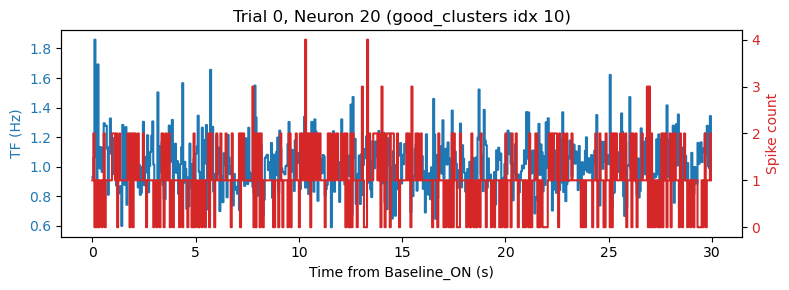

In [9]:
# --- Parameters ---
trial_idx = 0  # Index of trial to inspect
clu_idx = 10    # Index of neuron to inspect (in good_clusters)

# --- Get behav_data and NPX_probes ---
behav_data = subsession['behav_data']
trials = behav_data['trials_data_exp']
NPX_probes = subsession['NPX_probes']
spike_times = NPX_probes['st']
cluster_ids = NPX_probes['clu']
good_clusters = NPX_probes.get('cluster_id_KS_good', np.unique(cluster_ids))

# --- Extract TF sequence for the trial ---
trial = trials[trial_idx]
TF_vec_full = np.array(trial['St1TrialVector'])
TF_vec = TF_vec_full[::3]  # One value per 50 ms bin
n_bins = len(TF_vec)

# --- Get Baseline_ON time for this trial ---
if 'NI_events' in subsession and 'Baseline_ON' in subsession['NI_events']:
    baseline_on = subsession['NI_events']['Baseline_ON']
    if isinstance(baseline_on, dict) and 'rise_t' in baseline_on:
        baseline_on_times = np.array(baseline_on['rise_t']).flatten()
    else:
        baseline_on_times = np.array(baseline_on).flatten()
    t0 = baseline_on_times[trial_idx]
else:
    raise ValueError('Baseline_ON event not found!')

# --- Bin spikes for a single neuron ---
clu = good_clusters[clu_idx]
spike_times_clu = spike_times[cluster_ids == clu]
# Align to Baseline_ON for this trial
spikes_aligned = spike_times_clu - t0
bin_edges = np.arange(0, n_bins * 0.05 + 1e-8, 0.05)  # 50 ms bins
spike_counts, _ = np.histogram(spikes_aligned, bins=bin_edges)

# --- Plot TF sequence and spike counts ---
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(8, 3))
ax1.step(np.arange(n_bins) * 0.05, TF_vec, where='post', color='tab:blue', label='TF (Hz)')
ax1.set_ylabel('TF (Hz)', color='tab:blue')
ax1.set_xlabel('Time from Baseline_ON (s)')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.step(np.arange(n_bins) * 0.05, spike_counts, where='post', color='tab:red', label='Spike count')
ax2.set_ylabel('Spike count', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title(f'Trial {trial_idx}, Neuron {clu} (good_clusters idx {clu_idx})')
plt.tight_layout()
plt.show()

## Extract Fast Pulses and Visualize Peri-Fast-Pulse Spiking for a Single Neuron
This cell demonstrates how to identify all "fast pulses" (log2(TF) > 0.25) in a trial, extract their times, and align spikes from a single neuron to these events. This is the first step toward peri-fast-pulse analysis for TF-responsiveness.

Found 85 fast pulses in trial 0.


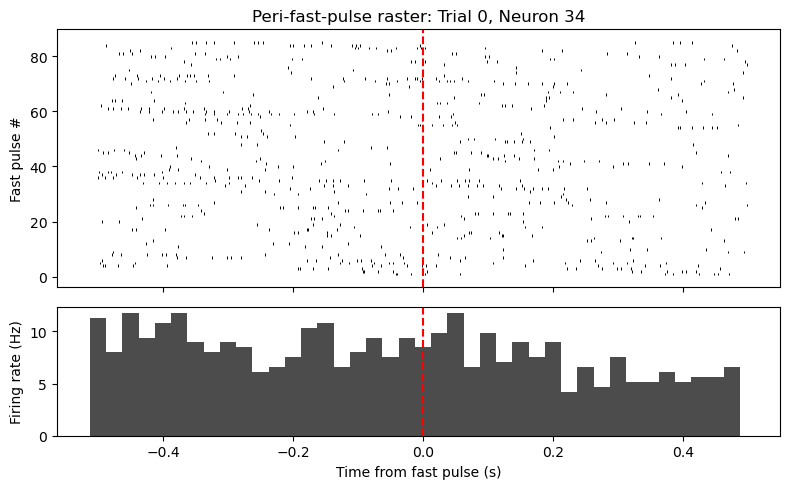

In [11]:
# --- Parameters ---
trial_idx = 0  # Trial to inspect
clu_idx = 20    # Neuron to inspect (in good_clusters)
fast_pulse_thresh = 0.25  # log2(TF) threshold for fast pulse
window = [-0.5, 0.5]      # Window (s) around each fast pulse
bin_size = 0.025          # Bin size for peri-event histogram (s)

# --- Get trial and TF vector ---
trial = trials[trial_idx]
TF_vec_full = np.array(trial['St1TrialVector'])
TF_vec = TF_vec_full[::3]  # One value per 50 ms bin
n_bins = len(TF_vec)

# --- Get Baseline_ON time for this trial ---
# (t0 already defined above)

# --- Find fast pulse bins ---
log2_TF = np.log2(TF_vec + 1e-8)  # Avoid log2(0)
fast_pulse_bins = np.where(log2_TF > fast_pulse_thresh)[0]
fast_pulse_times = fast_pulse_bins * 0.05 + t0  # Convert bin to absolute time (s)

print(f"Found {len(fast_pulse_times)} fast pulses in trial {trial_idx}.")

# --- Get spikes for this neuron ---
clu = good_clusters[clu_idx]
spike_times_clu = spike_times[cluster_ids == clu]

# --- Align spikes to each fast pulse ---
peri_spike_times = []
for t_fp in fast_pulse_times:
    aligned = spike_times_clu - t_fp
    peri_spike_times.append(aligned[(aligned >= window[0]) & (aligned <= window[1])])

# --- Flatten for histogram ---
all_aligned = np.concatenate(peri_spike_times) if len(peri_spike_times) > 0 else np.array([])
bins = np.arange(window[0], window[1] + bin_size, bin_size)
counts, _ = np.histogram(all_aligned, bins=bins)

# --- Plot peri-fast-pulse raster and histogram ---
import matplotlib.pyplot as plt
fig, (ax_ras, ax_psth) = plt.subplots(2, 1, figsize=(8, 5), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
# Raster
for i, spikes in enumerate(peri_spike_times):
    ax_ras.vlines(spikes, i + 0.5, i + 1.5, color='k', lw=0.7)
ax_ras.axvline(0, color='r', linestyle='--', label='Fast pulse')
ax_ras.set_ylabel('Fast pulse #')
ax_ras.set_title(f'Peri-fast-pulse raster: Trial {trial_idx}, Neuron {clu}')
# PSTH
ax_psth.bar(bins[:-1], counts / (len(fast_pulse_times) * bin_size) if len(fast_pulse_times) > 0 else 0, width=bin_size, color='k', alpha=0.7)
ax_psth.axvline(0, color='r', linestyle='--')
ax_psth.set_ylabel('Firing rate (Hz)')
ax_psth.set_xlabel('Time from fast pulse (s)')
plt.tight_layout()
plt.show()

**Explanation:**
- A "fast pulse" is defined as any 50 ms bin where log2(TF) > 0.25.
- All such bins are found in the selected trial, and their times are computed relative to Baseline_ON.
- Spikes from the selected neuron are aligned to each fast pulse, and a peri-event raster and histogram (PFPTH) are plotted.
- This approach can be extended to all trials and neurons for full TF-responsiveness analysis.

## Diagnostic: Check Spiking and Fast Pulse Alignment in Trial
This cell helps debug empty peri-fast-pulse plots by showing spike activity, fast pulse times, and trial outcome.

Total spikes for neuron 34 in trial: 225
Spikes within peri-fast-pulse windows: 683


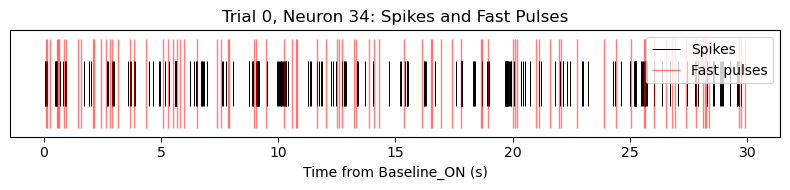

In [12]:
# --- Diagnostic for peri-fast-pulse analysis ---
# Print trial outcome and duration if available
if 'outcome' in trial:
    print(f"Trial {trial_idx} outcome: {trial['outcome']}")
if 'trial_length' in trial:
    print(f"Trial {trial_idx} duration: {trial['trial_length']:.2f} s")

# Print number of spikes for this neuron in the trial
n_spikes_total = np.sum((spike_times_clu >= t0) & (spike_times_clu < t0 + n_bins * 0.05))
print(f"Total spikes for neuron {clu} in trial: {n_spikes_total}")

# Print number of spikes within peri-fast-pulse windows
n_spikes_peri = sum(len(s) for s in peri_spike_times)
print(f"Spikes within peri-fast-pulse windows: {n_spikes_peri}")

# Plot spike raster for the whole trial, with fast pulses marked
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 2))
# Plot all spikes for this neuron in the trial
spikes_in_trial = spike_times_clu[(spike_times_clu >= t0) & (spike_times_clu < t0 + n_bins * 0.05)] - t0
ax.vlines(spikes_in_trial, 0.5, 1.5, color='k', lw=0.7, label='Spikes')
# Mark fast pulse times
fast_pulse_times_rel = fast_pulse_times - t0
ax.vlines(fast_pulse_times_rel, 0, 2, color='r', lw=1, alpha=0.5, label='Fast pulses')
ax.set_ylim(-0.2, 2.2)
ax.set_xlabel('Time from Baseline_ON (s)')
ax.set_yticks([])
ax.set_title(f'Trial {trial_idx}, Neuron {clu}: Spikes and Fast Pulses')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Explanation:**
- Prints the trial outcome and duration (if available).
- Shows the total number of spikes for the neuron in the trial, and the number within peri-fast-pulse windows.
- Plots all spikes for the neuron in the trial, with fast pulse times marked in red.
- Use this to check if the neuron is silent, if fast pulses are present, and if spike/event alignment is correct.

## Scan for Neurons with Spikes in Peri-Fast-Pulse Windows (Current Trial)
This cell scans all clusters in the current trial and reports which neurons have spikes within peri-fast-pulse windows. It helps you quickly find responsive neurons for visualization.

In [16]:
responsive_neurons = []
window = [-0.5, 0.5]  # Use same peri-event window as before
bin_size = 0.025

for idx, clu in enumerate(good_clusters):
    spike_times_clu = spike_times[cluster_ids == clu]
    # Align to Baseline_ON for this trial
    spikes_aligned = spike_times_clu - t0
    # Find fast pulse bins for this trial (already computed above)
    peri_spike_times = []
    for t_fp in fast_pulse_times:
        aligned = spike_times_clu - t_fp
        peri_spike_times.append(aligned[(aligned >= window[0]) & (aligned <= window[1])])
    n_spikes_peri = sum(len(s) for s in peri_spike_times)
    if n_spikes_peri > 0:
        responsive_neurons.append((idx, clu, n_spikes_peri))

if responsive_neurons:
    print(f"Found {len(responsive_neurons)} responsive neurons in trial {trial_idx}:")
    for idx, clu, n in responsive_neurons:
        print(f"  good_clusters idx {idx}, cluster ID {clu}: {n} spikes in peri-fast-pulse windows")
else:
    print(f"No responsive neurons found in trial {trial_idx}.")

Found 176 responsive neurons in trial 0:
  good_clusters idx 1, cluster ID 2: 698 spikes in peri-fast-pulse windows
  good_clusters idx 2, cluster ID 4: 5 spikes in peri-fast-pulse windows
  good_clusters idx 3, cluster ID 7: 215 spikes in peri-fast-pulse windows
  good_clusters idx 4, cluster ID 8: 297 spikes in peri-fast-pulse windows
  good_clusters idx 5, cluster ID 9: 1140 spikes in peri-fast-pulse windows
  good_clusters idx 7, cluster ID 12: 1523 spikes in peri-fast-pulse windows
  good_clusters idx 8, cluster ID 16: 210 spikes in peri-fast-pulse windows
  good_clusters idx 9, cluster ID 18: 437 spikes in peri-fast-pulse windows
  good_clusters idx 10, cluster ID 20: 1764 spikes in peri-fast-pulse windows
  good_clusters idx 11, cluster ID 22: 5 spikes in peri-fast-pulse windows
  good_clusters idx 12, cluster ID 23: 8 spikes in peri-fast-pulse windows
  good_clusters idx 13, cluster ID 24: 438 spikes in peri-fast-pulse windows
  good_clusters idx 14, cluster ID 25: 648 spikes i

**Explanation:**
- This cell scans all clusters in the current trial and checks for spikes within ±0.5 s of any fast pulse.
- It prints the indices and IDs of neurons with at least one spike in any peri-fast-pulse window.
- Use the reported indices to set `clu_idx` for visualization in the earlier cells.

## Compute and Plot Peri-Fast-Pulse PSTHs for All Fast Pulses in the Session (All Trials)
This cell collects all fast pulse times across all trials, aligns spikes from a selected neuron to these events, and plots the peri-fast-pulse raster and PSTH for the entire session.

Total fast pulses in session: 70191


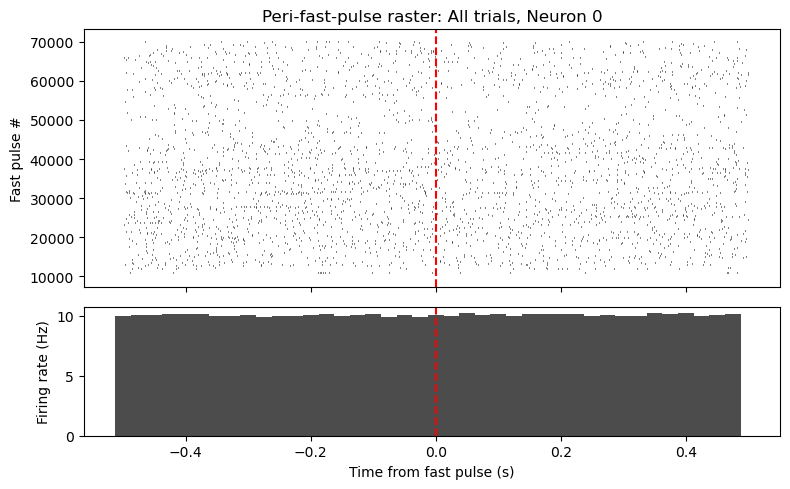

In [13]:
# --- Parameters ---
clu_idx = 0  # Neuron to inspect (in good_clusters)
fast_pulse_thresh = 0.25
window = [-0.5, 0.5]
bin_size = 0.025

# --- Collect all fast pulse times across all trials ---
all_fast_pulse_times = []
all_trial_t0 = []
for trial_idx, trial in enumerate(trials):
    TF_vec_full = np.array(trial['St1TrialVector'])
    TF_vec = TF_vec_full[::3]
    n_bins = len(TF_vec)
    # Get Baseline_ON for this trial
    if 'NI_events' in subsession and 'Baseline_ON' in subsession['NI_events']:
        baseline_on = subsession['NI_events']['Baseline_ON']
        if isinstance(baseline_on, dict) and 'rise_t' in baseline_on:
            baseline_on_times = np.array(baseline_on['rise_t']).flatten()
        else:
            baseline_on_times = np.array(baseline_on).flatten()
        t0 = baseline_on_times[trial_idx]
    else:
        continue  # skip if no Baseline_ON
    log2_TF = np.log2(TF_vec + 1e-8)
    fast_pulse_bins = np.where(log2_TF > fast_pulse_thresh)[0]
    fast_pulse_times = fast_pulse_bins * 0.05 + t0
    all_fast_pulse_times.extend(fast_pulse_times)
    all_trial_t0.append(t0)

all_fast_pulse_times = np.array(all_fast_pulse_times)
print(f"Total fast pulses in session: {len(all_fast_pulse_times)}")

# --- Get spikes for this neuron ---
clu = good_clusters[clu_idx]
spike_times_clu = spike_times[cluster_ids == clu]

# --- Align spikes to all fast pulses ---
peri_spike_times = []
for t_fp in all_fast_pulse_times:
    aligned = spike_times_clu - t_fp
    peri_spike_times.append(aligned[(aligned >= window[0]) & (aligned <= window[1])])

# --- Flatten for histogram ---
all_aligned = np.concatenate(peri_spike_times) if len(peri_spike_times) > 0 else np.array([])
bins = np.arange(window[0], window[1] + bin_size, bin_size)
counts, _ = np.histogram(all_aligned, bins=bins)

# --- Plot peri-fast-pulse raster and histogram for all fast pulses in session ---
import matplotlib.pyplot as plt
fig, (ax_ras, ax_psth) = plt.subplots(2, 1, figsize=(8, 5), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
# Raster
for i, spikes in enumerate(peri_spike_times):
    ax_ras.vlines(spikes, i + 0.5, i + 1.5, color='k', lw=0.7)
ax_ras.axvline(0, color='r', linestyle='--', label='Fast pulse')
ax_ras.set_ylabel('Fast pulse #')
ax_ras.set_title(f'Peri-fast-pulse raster: All trials, Neuron {clu}')
# PSTH
ax_psth.bar(bins[:-1], counts / (len(all_fast_pulse_times) * bin_size) if len(all_fast_pulse_times) > 0 else 0, width=bin_size, color='k', alpha=0.7)
ax_psth.axvline(0, color='r', linestyle='--')
ax_psth.set_ylabel('Firing rate (Hz)')
ax_psth.set_xlabel('Time from fast pulse (s)')
plt.tight_layout()
plt.show()

**Explanation:**
- This cell aggregates all fast pulse times across all trials in the session.
- Spikes from the selected neuron are aligned to all fast pulses, and a peri-event raster and PSTH are plotted for the session.
- This gives a more complete view of TF-responsiveness for the neuron across the entire experiment.